<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/graviational_wave_GW150914.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIGO  Graviational Waves**

In [ ]:
# gwpy and h5py for LIGOs HDF5 data
!pip install h5py gwpy ja gwosc PyWavelets gwpy matplotlib -q

In [ ]:
import numpy as np
from gwpy.timeseries import TimeSeries
from gwpy.plot import Plot

In [ ]:
# Fetch LIGO data for GW150914 event
def load_ligo_data(event='GW150914', detector='H1', duration=32):
    # Start time of the event (GPS timestamp)
    event_time = 1126259462  # GW150914 event time in GPS seconds

    # Fetch the strain data around the event
    start_time = event_time - duration // 2
    end_time = event_time + duration // 2

    # Fetch strain data for a specific detector (H1 or L1)
    data = TimeSeries.fetch_open_data(detector, start_time, end_time, cache=True)
    return data

# Load strain data for Hanford (H1) and Livingston (L1) detectors
h1_data = load_ligo_data(event='GW150914', detector='H1')
l1_data = load_ligo_data(event='GW150914', detector='L1')

# Print some basic info about the data
print("Hanford Data (H1):", h1_data)
print("Livingston Data (L1):", l1_data)

Hanford Data (H1): TimeSeries([2.17704028e-19, 2.08763900e-19, 2.39681183e-19, ...,
            3.55365541e-20, 6.33533516e-20, 7.58121195e-20]
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
Livingston Data (L1): TimeSeries([-1.04289994e-18, -1.03586274e-18, -9.89322445e-19,
            ..., -1.01767748e-18, -9.82876816e-19,
            -9.59276974e-19]
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


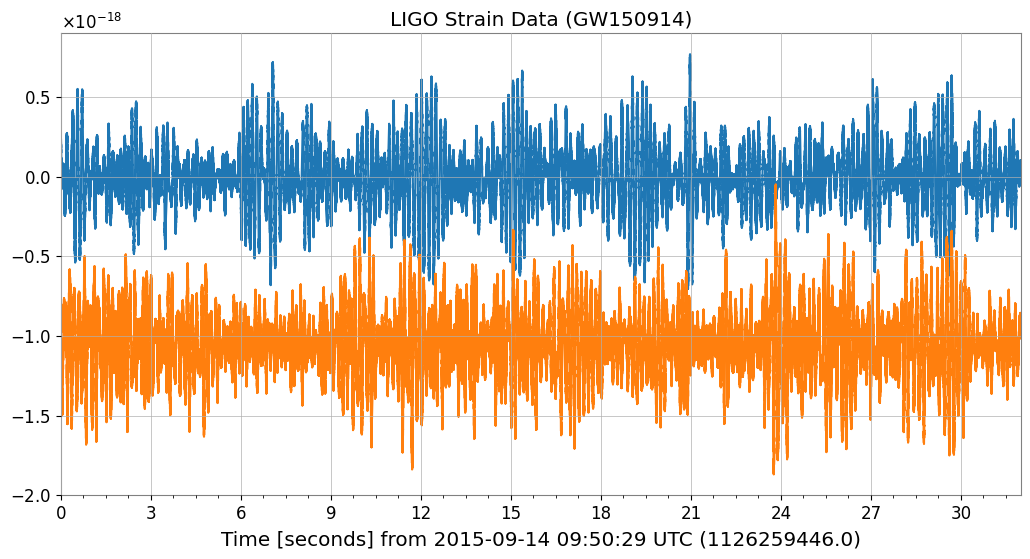

In [ ]:
# Plot raw strain data for Hanford (H1) and Livingston (L1)
plot = Plot(h1_data, l1_data, title="LIGO Strain Data (GW150914)")
plot.show()

In [ ]:
# Access and print metadata
print("Hanford Data Summary:")
print(f"Start Time: {h1_data.times.value[0]} GPS seconds")
print(f"End Time: {h1_data.times.value[-1]} GPS seconds")
print(f"Sampling Rate: {h1_data.sample_rate} Hz")
print(f"Duration: {h1_data.duration.value} seconds")
print(f"Data Units: {h1_data.unit}")

print("\nLivingston Data Summary:")
print(f"Start Time: {l1_data.times.value[0]} GPS seconds")
print(f"End Time: {l1_data.times.value[-1]} GPS seconds")
print(f"Sampling Rate: {l1_data.sample_rate} Hz")
print(f"Duration: {l1_data.duration.value} seconds")
print(f"Data Units: {l1_data.unit}")

Hanford Data Summary:
Start Time: 1126259446.0 GPS seconds
End Time: 1126259477.9997559 GPS seconds
Sampling Rate: 4096.0 Hz Hz
Duration: 32.0 seconds
Data Units: 

Livingston Data Summary:
Start Time: 1126259446.0 GPS seconds
End Time: 1126259477.9997559 GPS seconds
Sampling Rate: 4096.0 Hz Hz
Duration: 32.0 seconds
Data Units: 


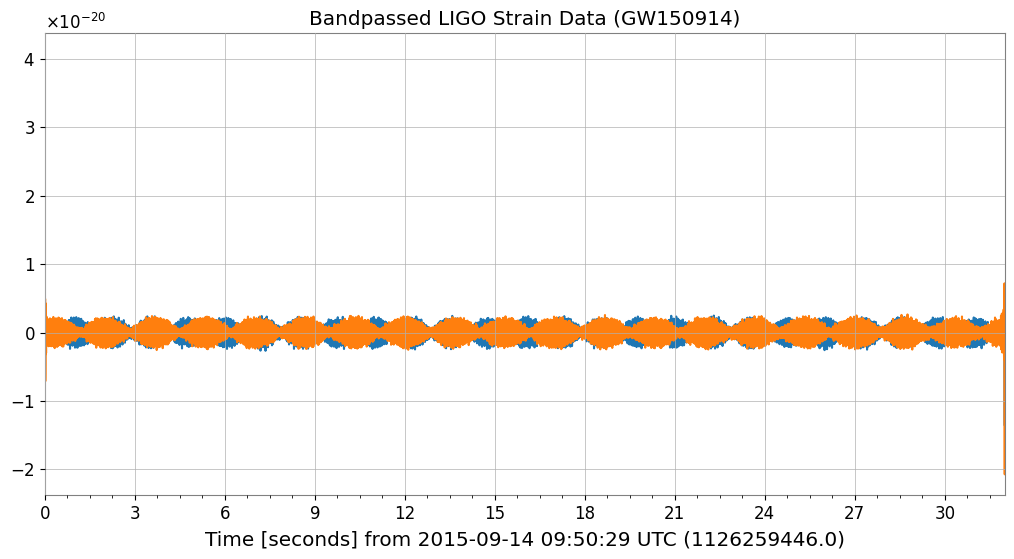

In [ ]:
# Apply a bandpass filter between 30 Hz and 300 Hz
# Gravitational wave signals in frequency between 30-300 Hz
# Remove unwanted low abd high fequency
h1_data_bp = h1_data.bandpass(30, 300)
l1_data_bp = l1_data.bandpass(30, 300)

# Plot the bandpassed data
plot = Plot(h1_data_bp, l1_data_bp, title="Bandpassed LIGO Strain Data (GW150914)")
plot.show()

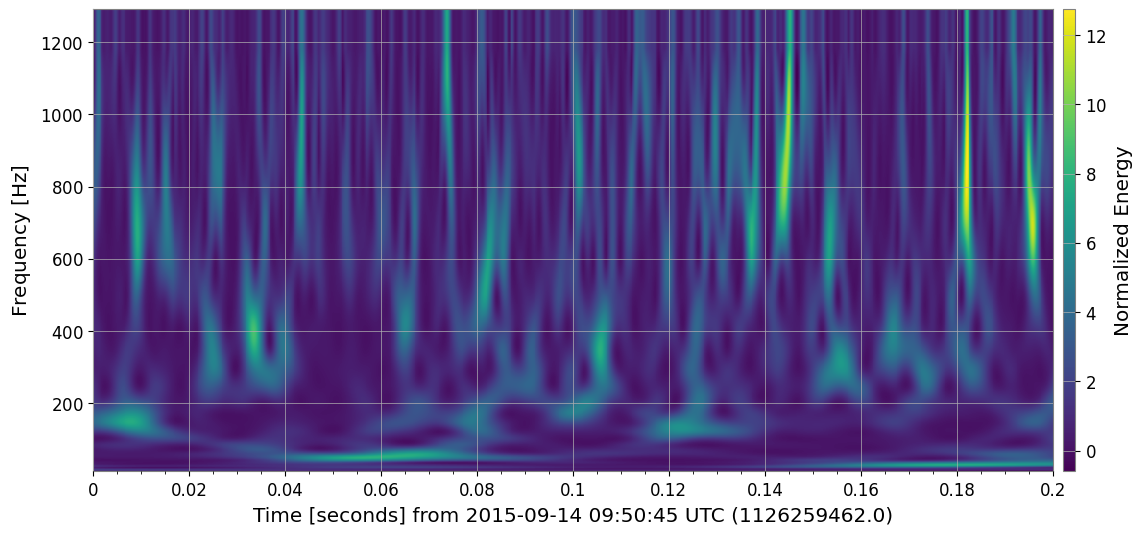

In [ ]:
# Apply whitening to strain data. Makes noise spectrum flat across frequencies. Enhances gravitational wave signal.
h1_data_white = h1_data_bp.whiten()
l1_data_white = l1_data_bp.whiten()
#plot = Plot(h1_data_white, l1_data_white, title="Whitened LIGO Strain Data (GW150914)")

# Generate a Q-transform plot of the whitened data
# Time frequency viszalisation (q transform) for short duratiom signals
q_transform_h1 = h1_data_white.q_transform(outseg=(1126259462, 1126259462 + 0.2))

# Plot the Q-transform (time-frequency representation)
plot = q_transform_h1.plot()
plot.colorbar(label="Normalized Energy")
plot.show()

**Explore data from multiple events using the Gravitational-Wave Open Science Center (GWOSC)**

In [ ]:
# gwosc provides access to all detected events
from gwosc import datasets

# List all available events
events = datasets.find_datasets(type="event")
print(f"Available events: {events}")

# Get the GPS time for a specific event
event_name = 'GW150914'
gps_time = datasets.event_gps(event_name)
print(f"GPS Time for {event_name}: {gps_time}")

Available events: ['151008-v1', '151012.2-v1', '151116-v1', '161202-v1', '161217-v1', '170208-v1', '170219-v1', '170405-v1', '170412-v1', '170423-v1', '170616-v1', '170630-v1', '170705-v1', '170720-v1', '190924_232654-v1', '191118_212859-v1', '191223_014159-v1', '191225_215715-v1', '200114_020818-v1', '200121_031748-v1', '200201_203549-v1', '200214_224526-v1', '200214_224526-v2', '200219_201407-v1', '200311_103121-v1', 'GRB051103-v1', 'GW150914-v1', 'GW150914-v2', 'GW150914-v3', 'GW151012-v1', 'GW151012-v2', 'GW151012-v3', 'GW151226-v1', 'GW151226-v2', 'GW170104-v1', 'GW170104-v2', 'GW170608-v1', 'GW170608-v2', 'GW170608-v3', 'GW170729-v1', 'GW170809-v1', 'GW170814-v1', 'GW170814-v2', 'GW170814-v3', 'GW170817-v1', 'GW170817-v2', 'GW170817-v3', 'GW170818-v1', 'GW170823-v1', 'GW190403_051519-v1', 'GW190408_181802-v1', 'GW190408_181802-v2', 'GW190412-v1', 'GW190412-v2', 'GW190412-v3', 'GW190412_053044-v4', 'GW190413_052954-v1', 'GW190413_052954-v2', 'GW190413_134308-v1', 'GW190413_134308-

In [ ]:
# Download the strain data for either the H1 (Hanford) or L1 (Livingston) detector,
# or download file manually or use following URL to download strain data directly.
# This will download the file H-H1_LOSC_4_V2-1126259446-32.hdf5, which contains the raw strain data around the event.

!wget https://www.gw-openscience.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5

import h5py

# Path to the downloaded HDF5 file
file_path = 'H-H1_LOSC_4_V2-1126259446-32.hdf5'  # Replace with your file path

# Open the HDF5 file and explore its structure
with h5py.File(file_path, 'r') as f:
    # List all groups and datasets in the file
    print("Keys in the file:", list(f.keys()))

    # Explore the 'strain' group if it exists
    if 'strain' in f.keys():
        strain_group = f['strain']
        print("\nDatasets in 'strain' group:", list(strain_group.keys()))

        # List all attributes in the 'strain' group
        print("\nAttributes in 'strain' group:", list(strain_group.attrs.keys()))

        # If 'SampleRate' exists, print it; otherwise, print a warning
        if 'SampleRate' in strain_group.attrs:
            print("SampleRate:", strain_group.attrs['SampleRate'])
        else:
            print("SampleRate attribute not found.")

import h5py
import numpy as np

# Open the HDF5 file
with h5py.File(file_path, 'r') as f:
    # Check if 'strain' group exists
    if 'strain' in f.keys():
        strain_data = f['strain']['Strain'][:]  # Extract strain data
        print("Strain data shape:", strain_data.shape)

        # Try accessing 'SampleRate', otherwise handle missing attribute
        if 'SampleRate' in f['strain'].attrs:
            sample_rate = f['strain'].attrs['SampleRate']
            print("Sample Rate:", sample_rate, "Hz")
        else:
            print("SampleRate attribute not found.")

        # Extract other attributes (like duration) if available
        if 'Duration' in f['strain'].attrs:
            duration = f['strain'].attrs['Duration']
            print("Duration:", duration, "seconds")
        else:
            print("Duration attribute not found.")


--2024-09-29 04:56:11--  https://www.gw-openscience.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5
Resolving www.gw-openscience.org (www.gw-openscience.org)... 131.215.113.72
Connecting to www.gw-openscience.org (www.gw-openscience.org)|131.215.113.72|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://gwosc.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5 [following]
--2024-09-29 04:56:11--  https://gwosc.org/s/events/GW150914/H-H1_LOSC_4_V2-1126259446-32.hdf5
Resolving gwosc.org (gwosc.org)... 131.215.113.72
Connecting to gwosc.org (gwosc.org)|131.215.113.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1040592 (1016K)
Saving to: ‘H-H1_LOSC_4_V2-1126259446-32.hdf5’

H-H1_LOSC_4_V2-1126 100%[===================>]   1016K  6.53MB/s    in 0.2s    

2024-09-29 04:56:12 (6.53 MB/s) - ‘H-H1_LOSC_4_V2-1126259446-32.hdf5’ saved [1040592/1040592]

Keys in the file: ['meta', 'quality', 'strain']

Datasets in 'strain

In [ ]:
# If metadata like SampleRate or Duration is missing from file, manually set typical values based on LIGO standards:
# Sample Rate: Typically, LIGO data has a sample rate of 4096 Hz or 16384 Hz.
# Duration: This can be inferred from the data array length and the sample rate.
# For example, if you don’t find the sample rate attribute, you can manually set it to 4096 Hz:

# Set default sample rate if not found
sample_rate = 4096  # sample rate not found, manually set to 4096 Hz
duration = len(strain_data) / sample_rate
print(f"Inferred Duration: {duration} seconds based on sample rate {sample_rate} Hz")

Inferred Duration: 32.0 seconds based on sample rate 4096 Hz


In [ ]:
import numpy as np
from gwpy.timeseries import TimeSeries

# Download LIGO's open data for a specific event (GW150914 as an example)
def load_ligo_event_data(event='GW150914'):
    start_time = 1126259462  # GW150914 start time
    end_time = start_time + 32  # 32 seconds of data

    # Download strain data for both Hanford and Livingston detectors
    h_data = TimeSeries.fetch_open_data('H1', start_time, end_time, cache=True)
    l_data = TimeSeries.fetch_open_data('L1', start_time, end_time, cache=True)

    return h_data, l_data

# Load data for both detectors
hanford_data, livingston_data = load_ligo_event_data()

# Resample data to a lower sample rate for easier computation
sample_rate = 4096  # LIGO's default is 16384, but downsample to 4096 for performance
hanford_data = hanford_data.resample(sample_rate)
livingston_data = livingston_data.resample(sample_rate)

# Extract raw data arrays
h_strain = hanford_data.value
l_strain = livingston_data.value

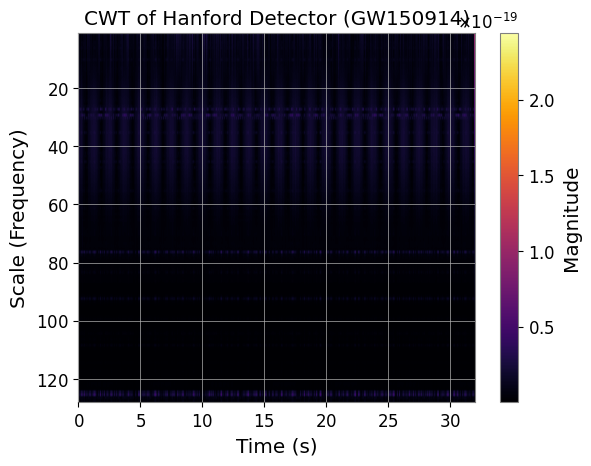

In [ ]:
import pywt
import matplotlib.pyplot as plt

# Perform Continuous Wavelet Transform (CWT) on the strain data
def cwt_transform(strain_data, wavelet='morl', scales=np.arange(1, 128)):
    coeffs, freqs = pywt.cwt(strain_data, scales, wavelet, 1 / sample_rate)
    return coeffs

# Apply CWT to the Hanford data
cwt_hanford = cwt_transform(h_strain)

# Visualize the time-frequency representation
plt.imshow(np.abs(cwt_hanford), aspect='auto', cmap='inferno', extent=[0, len(h_strain)/sample_rate, 1, 128])
plt.gca().invert_yaxis()
plt.colorbar(label='Magnitude')
plt.title('CWT of Hanford Detector (GW150914)')
plt.xlabel('Time (s)')
plt.ylabel('Scale (Frequency)')
plt.show()

In [1]:
!pip install gwpy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00


<ipython-input-5-6c49012e818b>:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


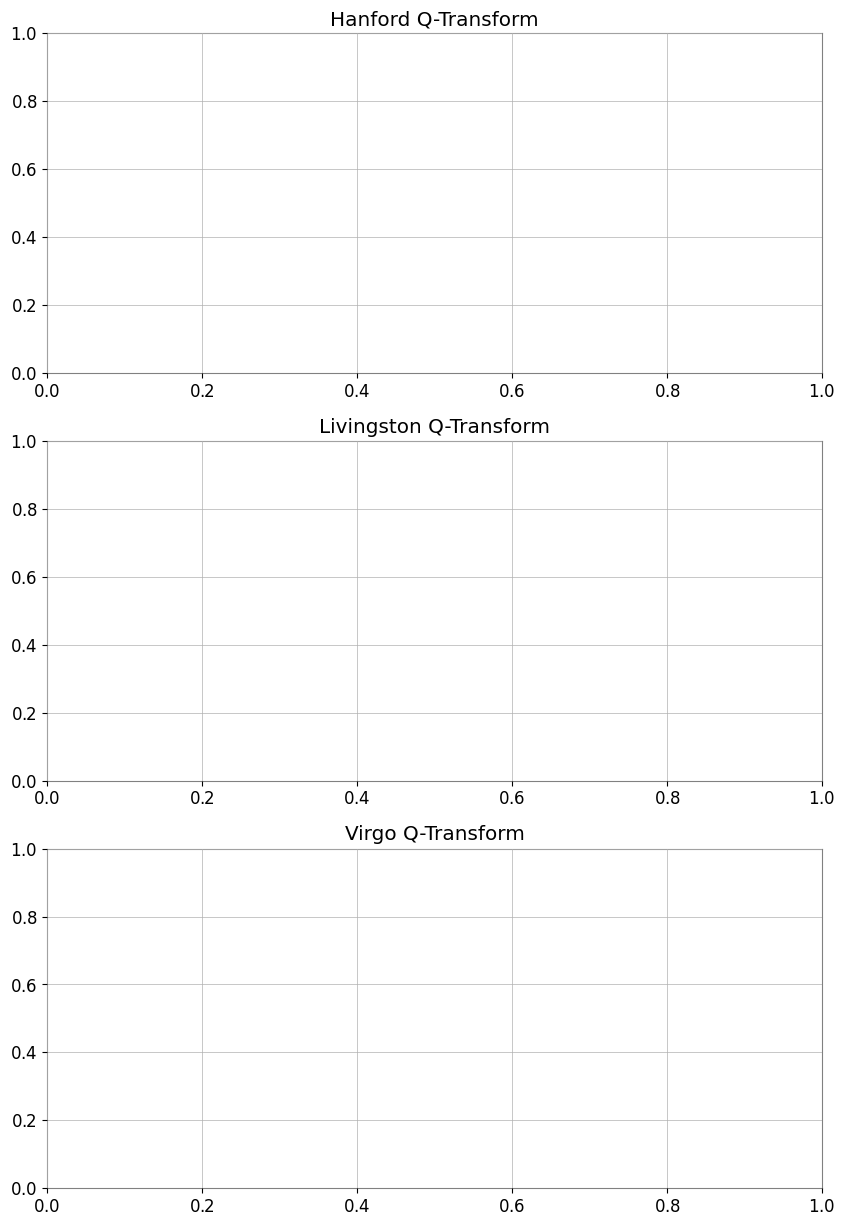

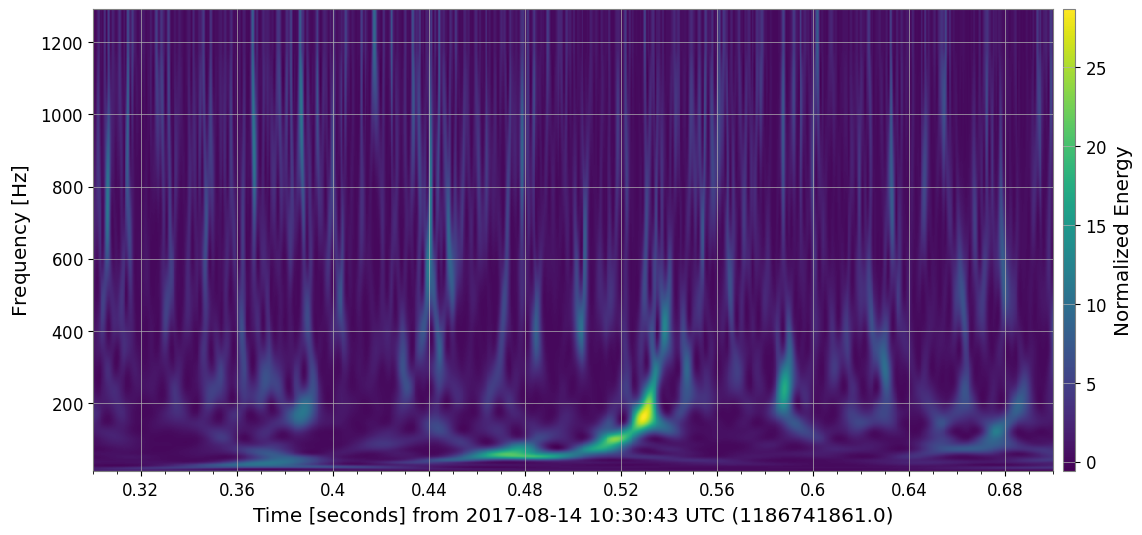

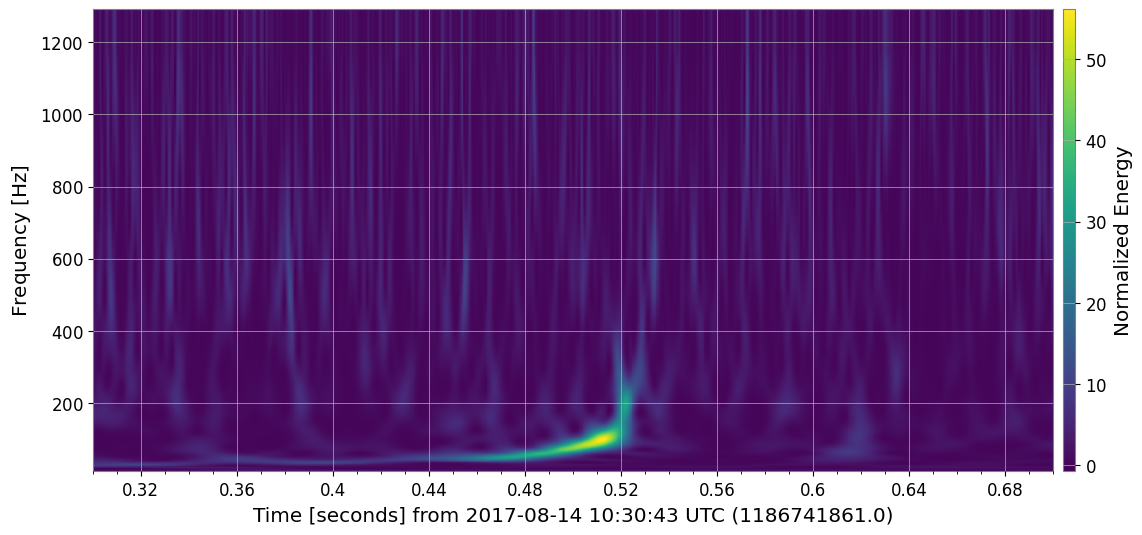

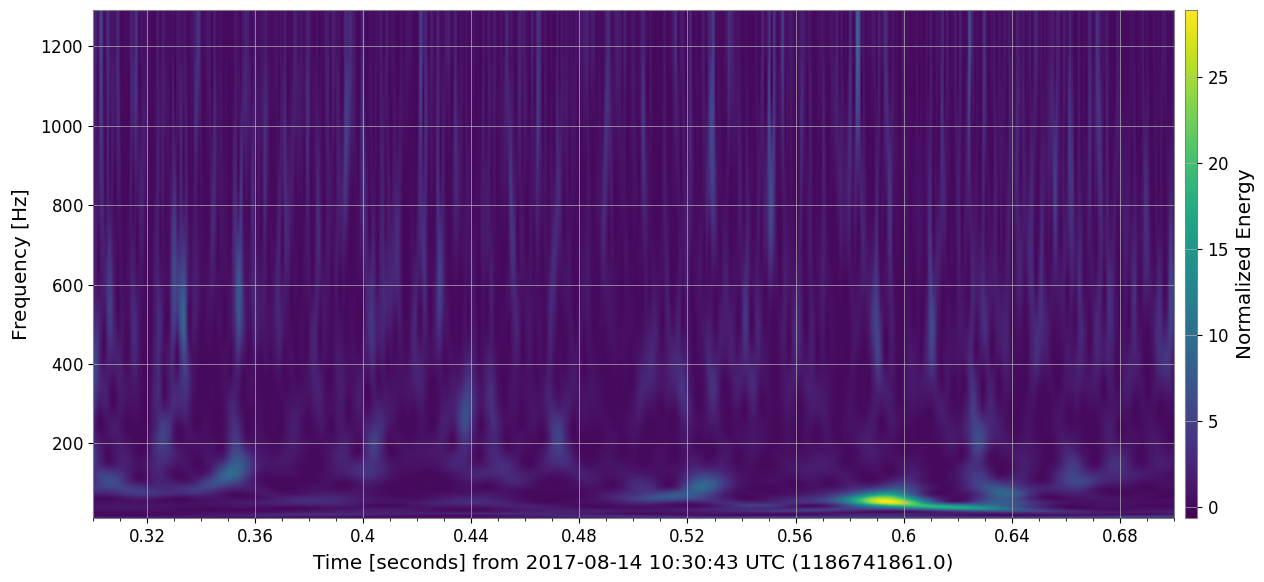

In [5]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# Define the event time for GW170814
event_time = 1186741861.5  # GPS time of GW170814

# Load strain data for Hanford, Livingston, and Virgo detectors
hanford_data = TimeSeries.fetch_open_data('H1', event_time - 16, event_time + 16, cache=True)
livingston_data = TimeSeries.fetch_open_data('L1', event_time - 16, event_time + 16, cache=True)
virgo_data = TimeSeries.fetch_open_data('V1', event_time - 16, event_time + 16, cache=True)

# Apply a bandpass filter between 30 and 400 Hz to remove noise outside this range
hanford_data_bp = hanford_data.bandpass(30, 400)
livingston_data_bp = livingston_data.bandpass(30, 400)
virgo_data_bp = virgo_data.bandpass(30, 400)

# Whiten the data to make the noise spectrum flat across frequencies
hanford_data_white = hanford_data_bp.whiten()
livingston_data_white = livingston_data_bp.whiten()
virgo_data_white = virgo_data_bp.whiten()

# Generate a Q-transform plot of the whitened data around the event time
q_transform_h1 = hanford_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))
q_transform_l1 = livingston_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))
q_transform_v1 = virgo_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))

# Create the plots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot()
plot_h1.colorbar(label="Normalized Energy")
axs[0].set_title("Hanford Q-Transform")

# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot()
plot_l1.colorbar(label="Normalized Energy")
axs[1].set_title("Livingston Q-Transform")

# Plot the Q-transform for Virgo
plot_v1 = q_transform_v1.plot()
plot_v1.colorbar(label="Normalized Energy")
axs[2].set_title("Virgo Q-Transform")

plt.tight_layout()
plt.show()